In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
print('Hello World!')
'Hello World!'

Hello World!


'Hello World!'

In [3]:
def square(x):
    return x * x

print('square() defined')

square() defined


In [4]:
num = random.randint(1, 10)
result = square(num)
print(f'{num} squared is {result}')

9 squared is 81


In [5]:
def selection_sort(arr):
    n = len(arr)
    sorted_arr = arr.copy()
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if sorted_arr[j] < sorted_arr[min_idx]:
                min_idx = j
        sorted_arr[i], sorted_arr[min_idx] = sorted_arr[min_idx], sorted_arr[i]
    return sorted_arr

test_list = [64, 25, 12, 22, 11]
print(f'Original: {test_list}')
print(f'Sorted:   {selection_sort(test_list)}')

Original: [64, 25, 12, 22, 11]
Sorted:   [11, 12, 22, 25, 64]


In [6]:
def test_selection_sort():
    test_cases = [
        ([64, 25, 12, 22, 11], [11, 12, 22, 25, 64]),
        ([1, 2, 3, 4, 5],     [1, 2, 3, 4, 5]),
        ([5, 4, 3, 2, 1],     [1, 2, 3, 4, 5]),
        ([1],                 [1]),
        ([],                  []),
        ([3, 1, 3, 2, 1],     [1, 1, 2, 3, 3]),
    ]
    all_passed = True
    for inp, exp in test_cases:
        res = selection_sort(inp)
        if res == exp:
            print(f'[PASS] {inp} -> {res}')
        else:
            print(f'[FAIL] {inp} -> {res} (expected {exp})')
            all_passed = False
    if all_passed:
        print(f'\nAll {len(test_cases)} tests passed!')
    return all_passed

test_selection_sort()

[PASS] [64, 25, 12, 22, 11] -> [11, 12, 22, 25, 64]
[PASS] [1, 2, 3, 4, 5] -> [1, 2, 3, 4, 5]
[PASS] [5, 4, 3, 2, 1] -> [1, 2, 3, 4, 5]
[PASS] [1] -> [1]
[PASS] [] -> []
[PASS] [3, 1, 3, 2, 1] -> [1, 1, 2, 3, 3]

All 6 tests passed!


True

In [7]:
df = pd.read_csv('fortune500.csv')
df.head()

,Year,Rank,Company,Revenue,Profit
0,1955,1,Amoco,1738.0,13411.8
1,1955,2,DuPont,29729.4,816.5
2,1955,3,General Electric,28281.6,5488.0
3,1955,4,Raytheon,29668.7,-
4,1955,5,Eastman Kodak,35057.9,18930.3


In [8]:
df.tail()

,Year,Rank,Company,Revenue,Profit
2545,2005,46,Wells Fargo,45067.5,5205.2
2546,2005,47,Oracle,11068.9,11305.9
2547,2005,48,Cisco Systems,45281.5,5302.9
2548,2005,49,Dow Chemical,11250.3,4607.3
2549,2005,50,Kindred Healthcare,21873.3,161.3


In [9]:
df.columns = ['year', 'rank', 'company', 'revenue', 'profit']
len(df)

2550

In [10]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit      object
dtype: object

In [11]:
non_numberic_profits = df.profit.str.contains('[^0-9.-]')
df.loc[non_numberic_profits].head()

,year,rank,company,revenue,profit
43,1955,44,Mobil,8649.5,N.A.
122,1957,23,Eli Lilly,22684.6,N.A.
129,1957,30,Wells Fargo,9382.4,N.A.
153,1958,4,Wendy's International,41333.9,N.A.
179,1958,30,UnitedHealth Group,13138.7,N.A.


In [12]:
len(df.profit[non_numberic_profits])

58

In [13]:
bin_sizes, _, _ = plt.hist(df.year[non_numberic_profits], bins=range(1955, 2006))

In [14]:
df = df.loc[~non_numberic_profits]
df.profit = pd.to_numeric(df.profit, errors='coerce')
df = df.dropna(subset=['profit'])

In [15]:
len(df)

2472

In [16]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit     float64
dtype: object

In [17]:
group_by_year = df.loc[:, ['year', 'revenue', 'profit']].groupby('year')
avgs = group_by_year.mean()
x = avgs.index
y1 = avgs.profit
y2 = avgs.revenue
def plot(x, y, ax, title, y_label):
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.plot(x, y)
    ax.margins(x=0, y=0)

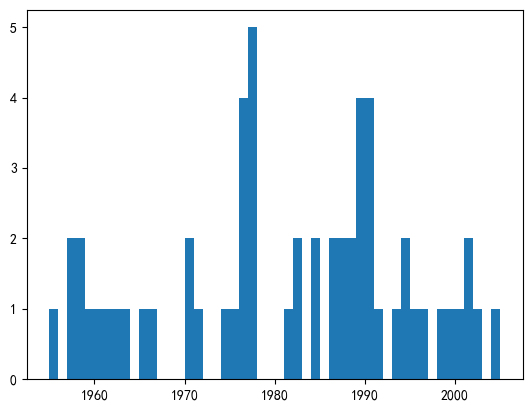

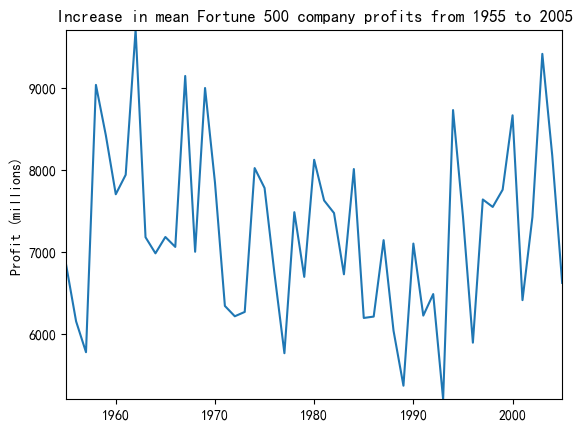

In [18]:
fig, ax = plt.subplots()
plot(x, y1, ax, 'Increase in mean Fortune 500 company profits from 1955 to 2005', 'Profit (millions)')
plt.show()


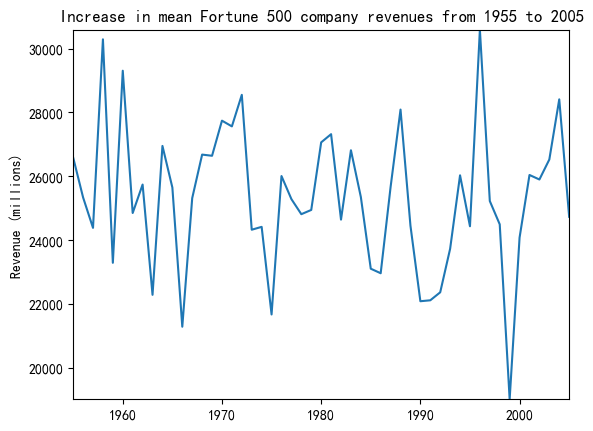

In [19]:
fig, ax = plt.subplots()
plot(x, y2, ax, 'Increase in mean Fortune 500 company revenues from 1955 to 2005', 'Revenue (millions)')
plt.show()


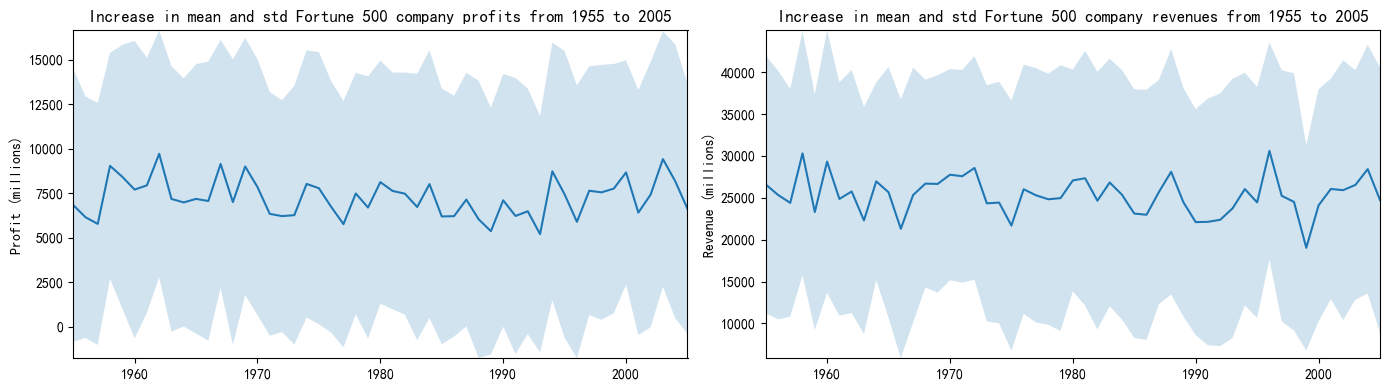

In [20]:
def plot_with_std(x, y, stds, ax, title, y_label):
    ax.fill_between(x, y - stds, y + stds, alpha=0.2)
    plot(x, y, ax, title, y_label)
fig, (ax1, ax2) = plt.subplots(ncols=2)
title = 'Increase in mean and std Fortune 500 company %s from 1955 to 2005'
stds1 = group_by_year.std().profit.values
stds2 = group_by_year.std().revenue.values
plot_with_std(x, y1.values, stds1, ax1, title % 'profits', 'Profit (millions)')
plot_with_std(x, y2.values, stds2, ax2, title % 'revenues', 'Revenue (millions)')
fig.set_size_inches(14, 4)
fig.tight_layout()
plt.show()
